In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [26]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [27]:
print(df.columns)
print(df.shape)
df.info()


Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')
(918, 12)
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [28]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [29]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [30]:
print(df.duplicated().sum())
#value counts of categorical features
categorical_features = df.drop(columns=["Age", "RestingBP", "Cholesterol", "FastingBS", "Oldpeak","MaxHR"]).columns
for feature in categorical_features:
    print(f"Value counts for {feature}:")
    print(df[feature].value_counts())
    print("\n")



0
Value counts for Sex:
Sex
M    725
F    193
Name: count, dtype: int64


Value counts for ChestPainType:
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


Value counts for RestingECG:
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


Value counts for ExerciseAngina:
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


Value counts for ST_Slope:
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


Value counts for HeartDisease:
HeartDisease
1    508
0    410
Name: count, dtype: int64




In [31]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


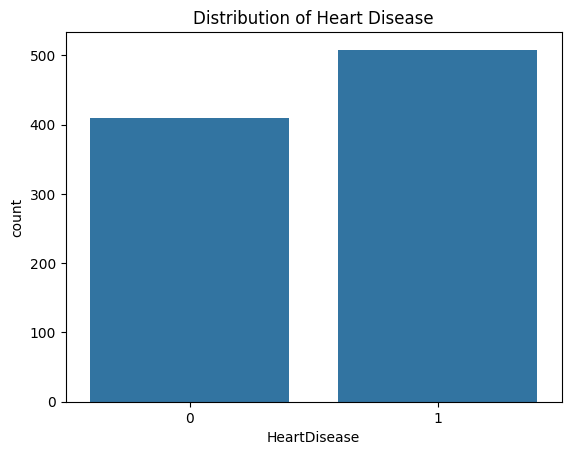

In [32]:
#plotting the distribution of target variable
sns.countplot(x="HeartDisease", data=df)
plt.title("Distribution of Heart Disease")
plt.show()


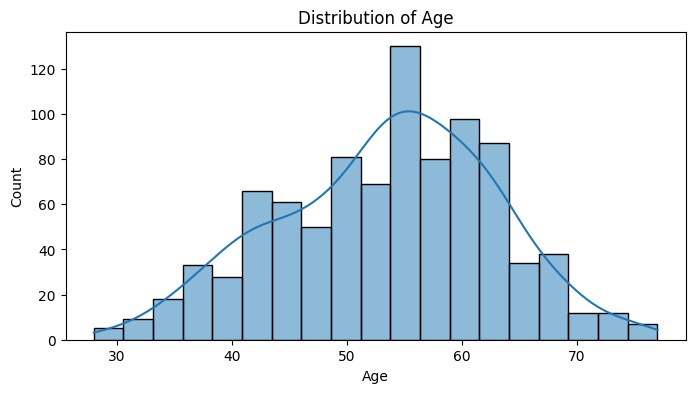

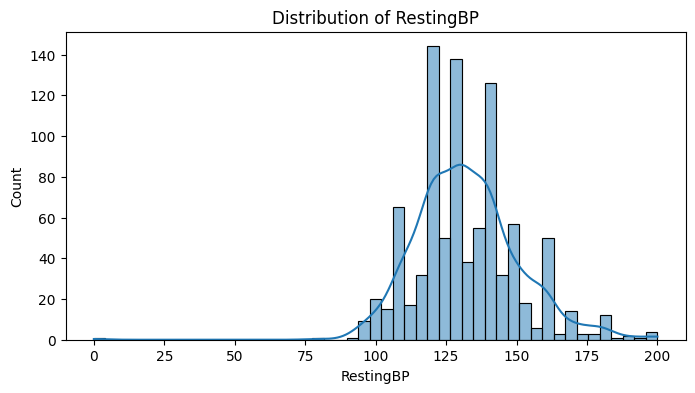

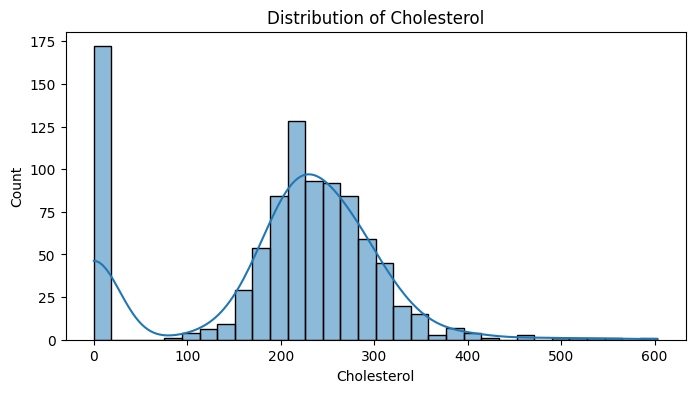

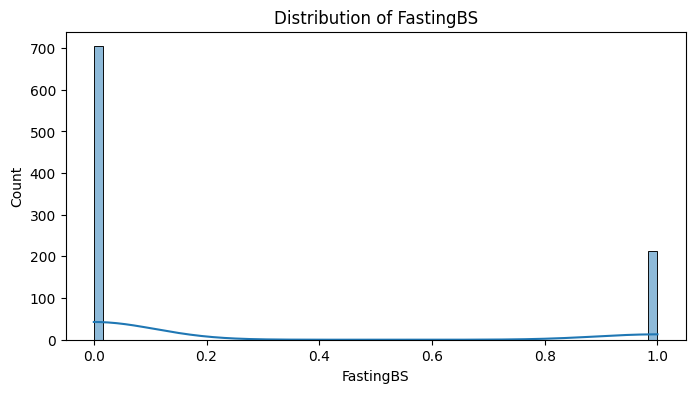

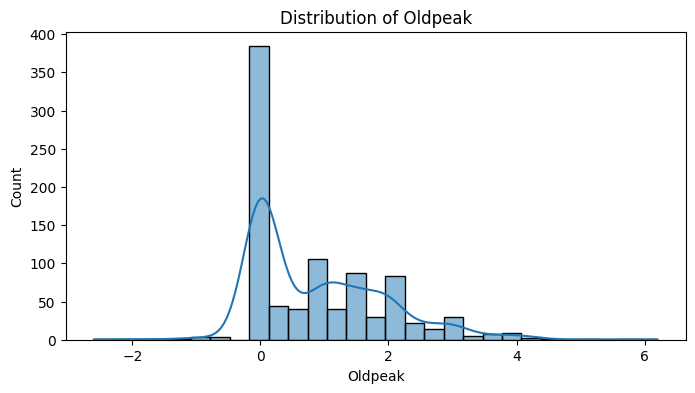

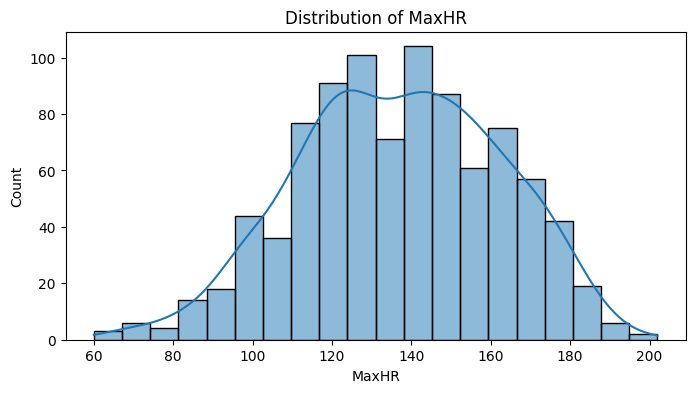

In [33]:
#distribution of numerical features
numerical_features = ["Age", "RestingBP", "Cholesterol", "FastingBS", "Oldpeak","MaxHR"]
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()  
    

In [34]:
df['Cholesterol'].value_counts()


Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [35]:
df['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

In [43]:
df[df['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,244.64,0,Normal,155,N,1.5,Flat,1


Cholesterol,RestingBP and FastingBS of a person cant be '0' its a wrong entry 

In [36]:
# fill the '0' values in 'Cholesterol' with the mean of the column excluding the '0' values
cholesterol_mean = df[df['Cholesterol'] != 0]['Cholesterol'].mean()
print(f"Mean Cholesterol (excluding '0' values): {cholesterol_mean}")
df['Cholesterol'] = df['Cholesterol'].replace(0, cholesterol_mean).round(2)
df.head()

Mean Cholesterol (excluding '0' values): 244.6353887399464


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


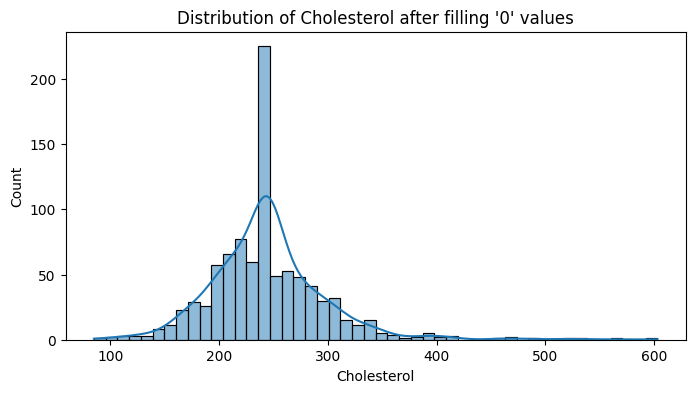

In [37]:
#plotting the cholesterol distribution after filling the '0' values
plt.figure(figsize=(8, 4))
sns.histplot(df['Cholesterol'], kde=True)
plt.title("Distribution of Cholesterol after filling '0' values")
plt.show()

In [44]:
#replacing '0' values in 'RestingBP' with the mean of the column excluding the '0' values
restingbp_mean = df[df['RestingBP'] != 0]['RestingBP'].mean()
print(f"Mean RestingBP (excluding '0' values): {restingbp_mean}")
df['RestingBP'] = df['RestingBP'].replace(0, restingbp_mean).round(2)
df['RestingBP']

Mean RestingBP (excluding '0' values): 132.54089422028352


0      140.0
1      160.0
2      130.0
3      138.0
4      150.0
       ...  
913    110.0
914    144.0
915    130.0
916    130.0
917    138.0
Name: RestingBP, Length: 918, dtype: float64

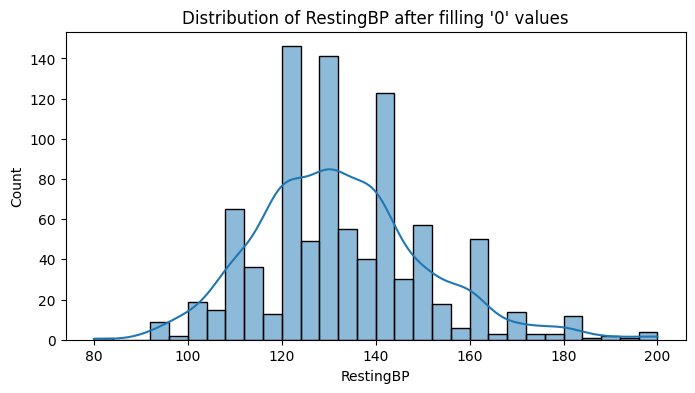

In [45]:
#plotting the RestingBP distribution after filling the '0' values
plt.figure(figsize=(8, 4))
sns.histplot(df['RestingBP'], kde=True)
plt.title("Distribution of RestingBP after filling '0' values")
plt.show()

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 86.2 KB


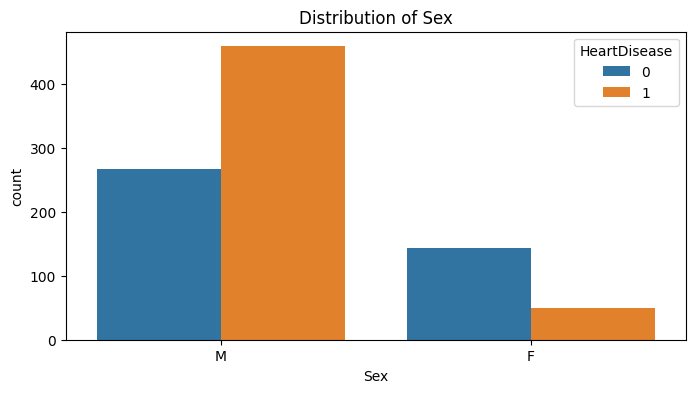

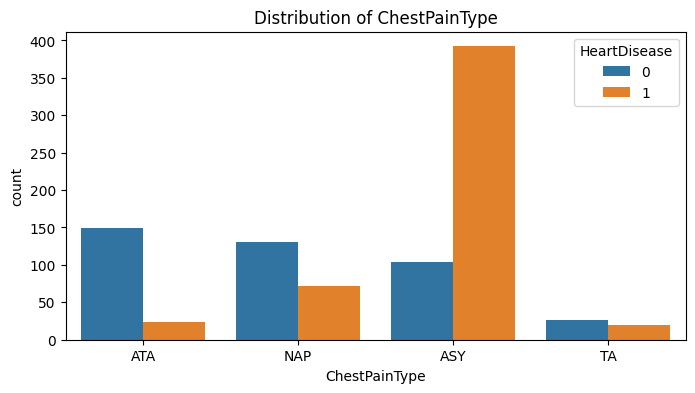

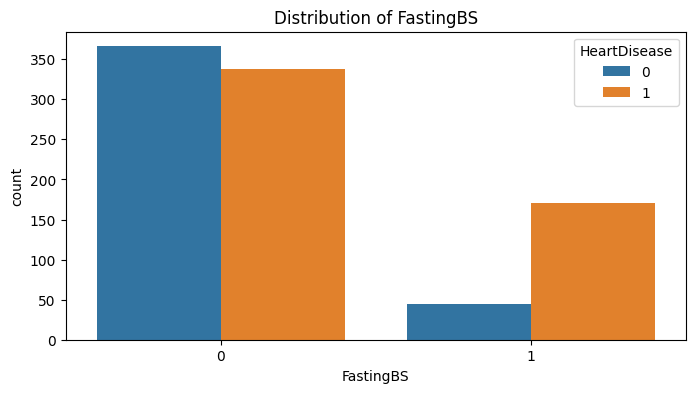

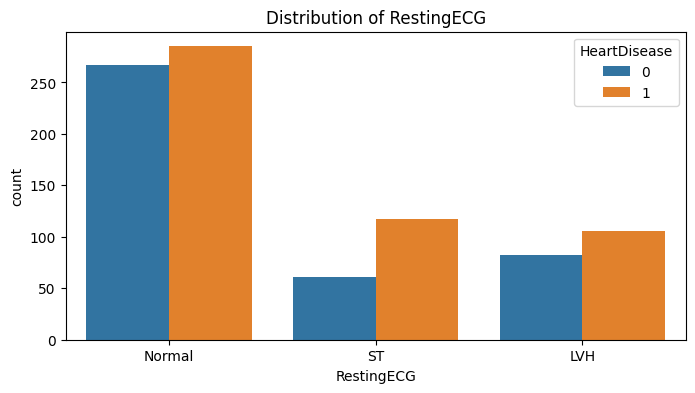

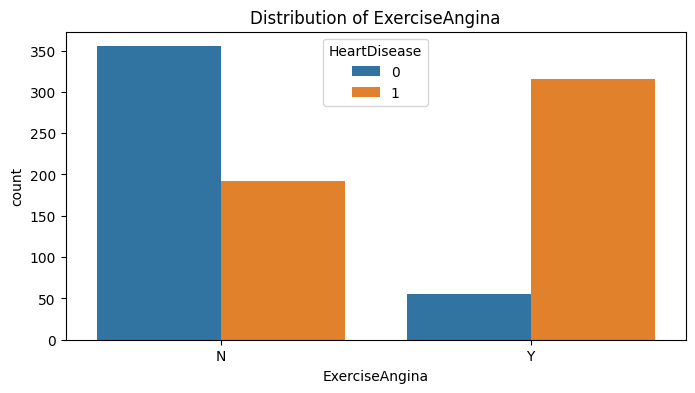

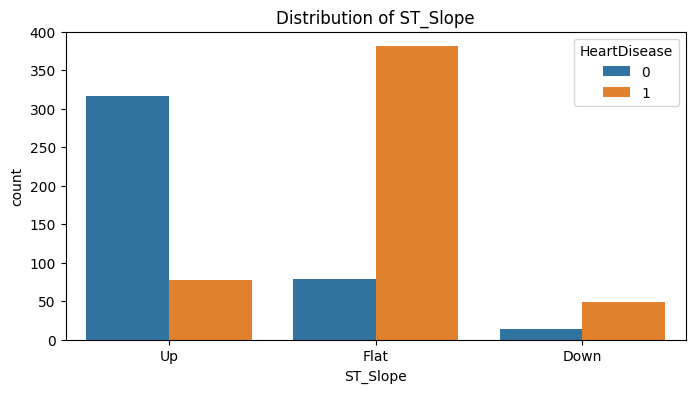

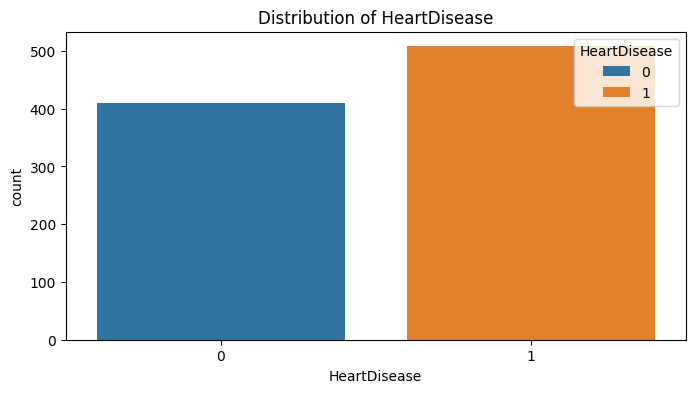

In [ ]:
#distribution of categorical features
Categorical_features = df.drop(columns=["Age", "RestingBP", "Cholesterol", "Oldpeak","MaxHR"]).columns
for feature in Categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=feature, data=df,hue="HeartDisease")
    plt.title(f"Distribution of {feature}")
    plt.show()

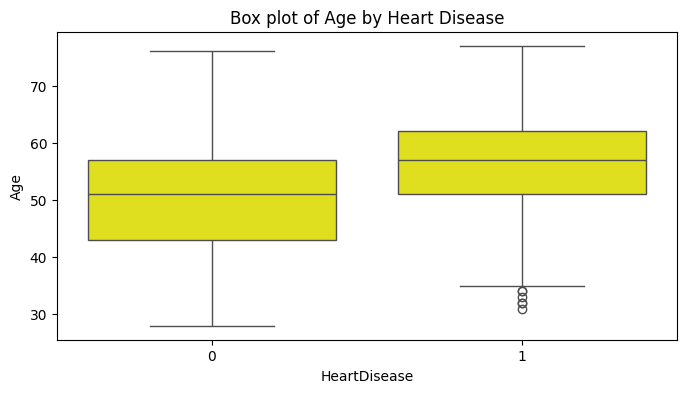

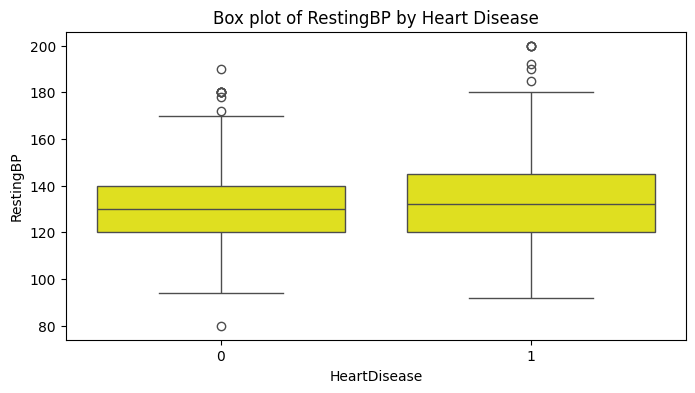

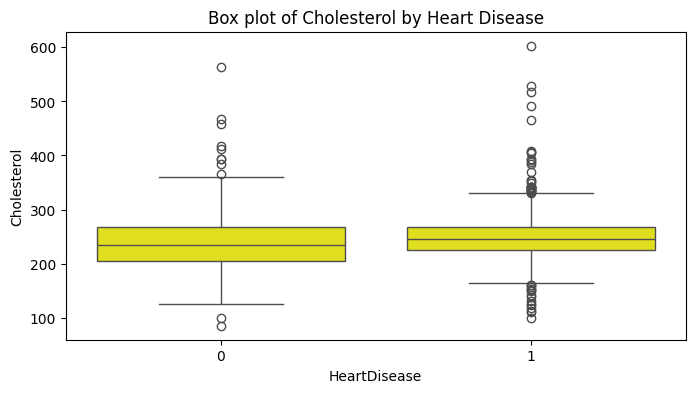

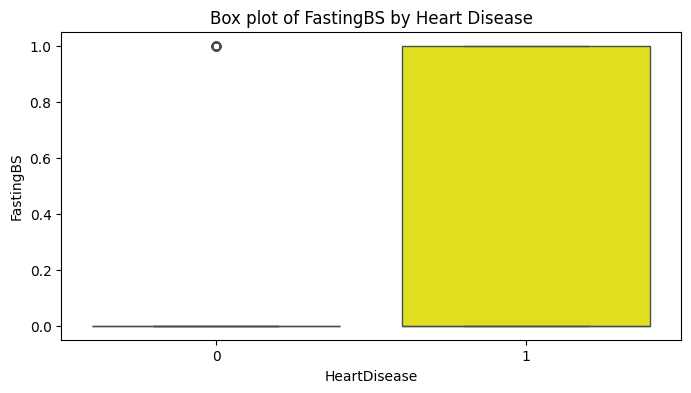

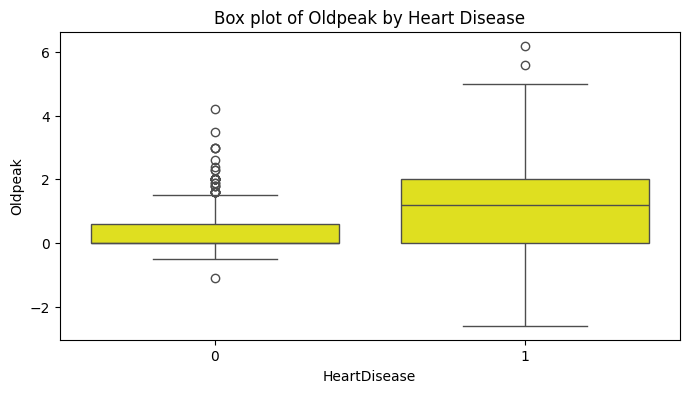

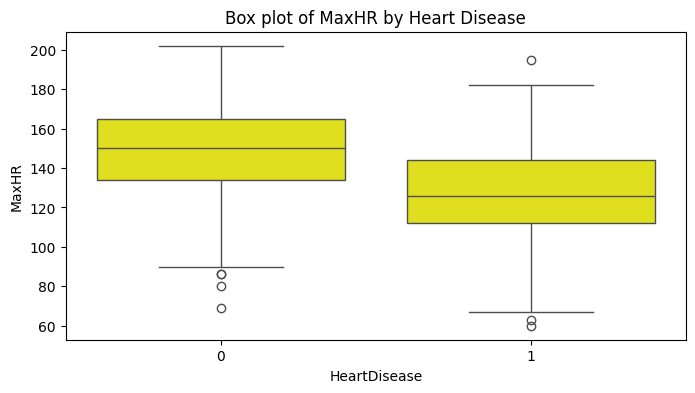

In [51]:
#Box plots for numerical features
numerical_features = ["Age", "RestingBP", "Cholesterol", "FastingBS", "Oldpeak","MaxHR"]
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x="HeartDisease", y=feature, data=df,color="Yellow")
    plt.title(f"Box plot of {feature} by Heart Disease")
    plt.show()

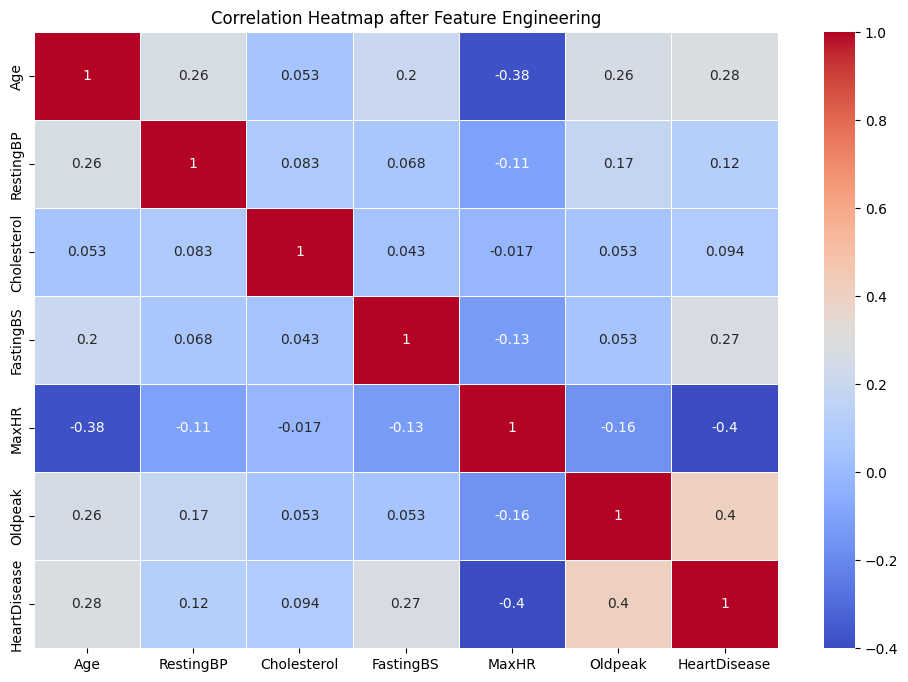

In [55]:
#correlation heatmap after feature engineering
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap after Feature Engineering")
plt.show()

In [59]:
df_encoded = pd.get_dummies(df)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [57]:
df_encoded = df_encoded.astype(int)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [60]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_F              918 non-null    bool   
 8   Sex_M              918 non-null    bool   
 9   ChestPainType_ASY  918 non-null    bool   
 10  ChestPainType_ATA  918 non-null    bool   
 11  ChestPainType_NAP  918 non-null    bool   
 12  ChestPainType_TA   918 non-null    bool   
 13  RestingECG_LVH     918 non-null    bool   
 14  RestingECG_Normal  918 non-null    bool   
 15  RestingECG_ST      918 non-null    bool   
 16  ExerciseAngina_N   918 non-null    bo

In [62]:
#scaling the numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_features = ["Age", "RestingBP", "Cholesterol", "Oldpeak","MaxHR"]
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832513,0,1.382928,-0.832432,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,-0.478484,1.527192,-1.212938,0,0.754157,0.105664,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.141317,0.719919,0,-1.525138,-0.832432,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,-0.584556,0.303619,-0.574908,0,-1.132156,0.574711,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,0.051881,0.971022,-0.931454,0,-0.581981,-0.832432,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [63]:
#lebel encoding the boolean features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
boolean_features =df_encoded.select_dtypes(include=["bool"]).columns
for feature in boolean_features:
    df_encoded[feature] = le.fit_transform(df_encoded[feature])
df_encoded.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832513,0,1.382928,-0.832432,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212938,0,0.754157,0.105664,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719919,0,-1.525138,-0.832432,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303619,-0.574908,0,-1.132156,0.574711,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971022,-0.931454,0,-0.581981,-0.832432,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [64]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    float64
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    float64
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_F              918 non-null    int64  
 8   Sex_M              918 non-null    int64  
 9   ChestPainType_ASY  918 non-null    int64  
 10  ChestPainType_ATA  918 non-null    int64  
 11  ChestPainType_NAP  918 non-null    int64  
 12  ChestPainType_TA   918 non-null    int64  
 13  RestingECG_LVH     918 non-null    int64  
 14  RestingECG_Normal  918 non-null    int64  
 15  RestingECG_ST      918 non-null    int64  
 16  ExerciseAngina_N   918 non-null    in

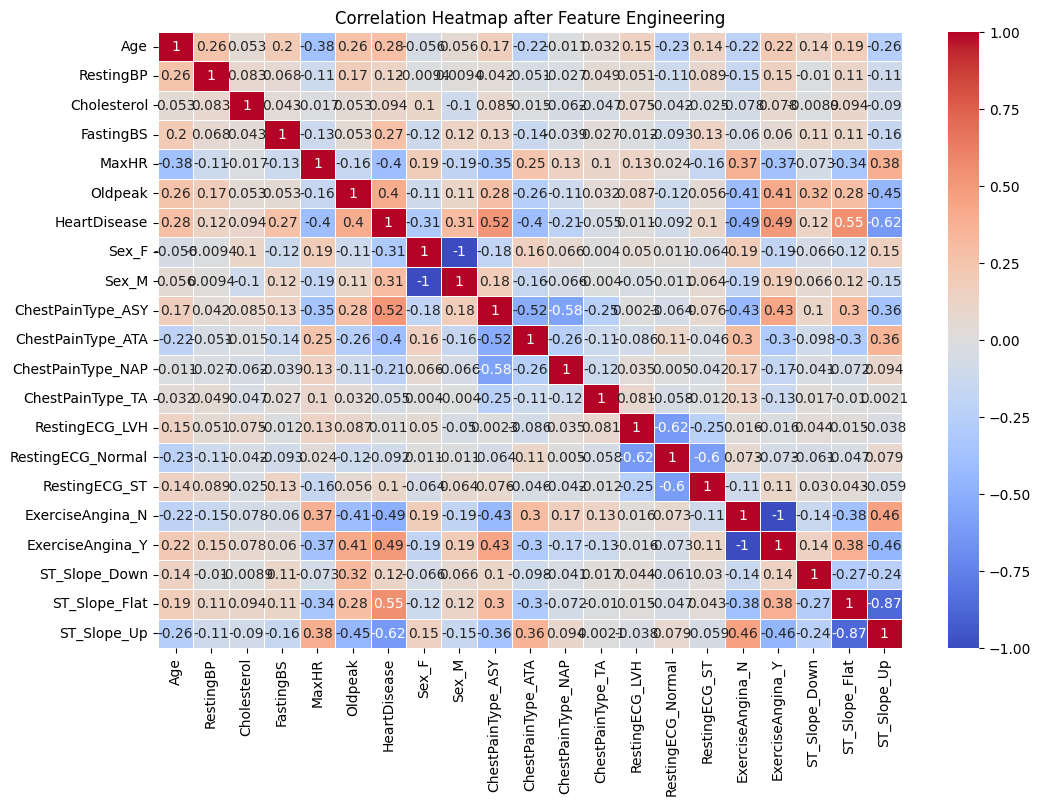

In [65]:
#correlation heatmap after feature engineering
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap after Feature Engineering")
plt.show()

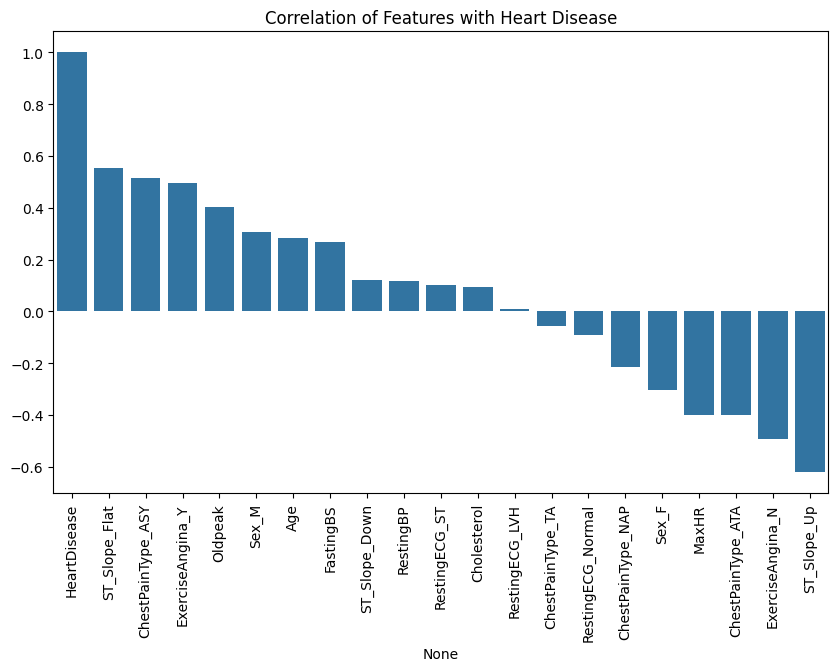

In [66]:
#plotting correlation of features with target variable HeartDisease
correlation_with_target = df_encoded.corr(numeric_only=True)["HeartDisease"].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_target.index, y=correlation_with_target.values)
plt.xticks(rotation=90)
plt.title("Correlation of Features with Heart Disease")
plt.show()

In [72]:
#Feature extraction using pearson correlation
from scipy.stats import pearsonr

selected_features = df_encoded.columns[df_encoded.columns != "HeartDisease"]
correlations = {
    feature: pearsonr(df_encoded[feature], df_encoded["HeartDisease"])[0] 
    for feature in selected_features
}

corelation_df = pd.DataFrame.from_dict(correlations, orient="index", columns=["PearsonCorrelation"])
corelation_df["AbsoluteCorrelation"] = corelation_df["PearsonCorrelation"].abs()
corelation_df = corelation_df.sort_values(by="AbsoluteCorrelation", ascending=False)
corelation_df


,PearsonCorrelation,AbsoluteCorrelation
ST_Slope_Up,-0.622164,0.622164
ST_Slope_Flat,0.554134,0.554134
ChestPainType_ASY,0.516716,0.516716
ExerciseAngina_N,-0.494282,0.494282
ExerciseAngina_Y,0.494282,0.494282
Oldpeak,0.403951,0.403951
ChestPainType_ATA,-0.401924,0.401924
MaxHR,-0.400421,0.400421
Sex_F,-0.305445,0.305445
Sex_M,0.305445,0.305445


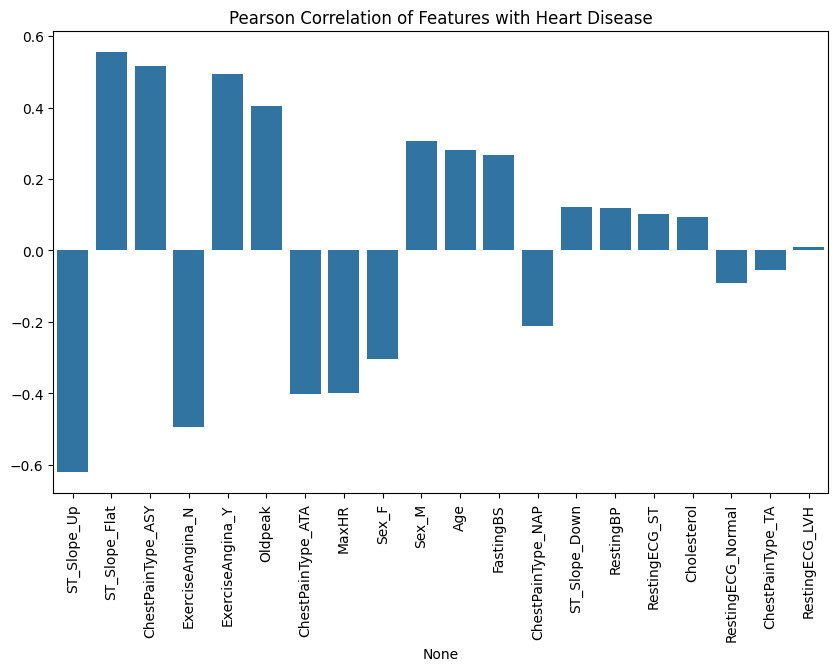

In [73]:
#plotting the pearson correlation of features with target variable HeartDisease
plt.figure(figsize=(10, 6))
sns.barplot(x=corelation_df.index, y=corelation_df["PearsonCorrelation"].values)
plt.xticks(rotation=90)
plt.title("Pearson Correlation of Features with Heart Disease")
plt.show()


In [75]:
#chi-square test for categorical features
from scipy.stats import chi2_contingency

alpha = 0.05

categorical_features = df_encoded.select_dtypes(include=["int64"]).columns[df_encoded.select_dtypes(include=["int64"]).columns != "HeartDisease"]
chi2_results = {}

for feature in categorical_features:
    contingency_table = pd.crosstab(df_encoded[feature], df_encoded['HeartDisease'])
    chi2_stat,p_value,_,_ = chi2_contingency(contingency_table)
    decision = "Reject Null Hypothesis(Keep feature)" if p_value < alpha else "Accept Null Hypothesis(Drop the feature)"
    chi2_results[feature]={
        "chi2_stat": chi2_stat,
        "p_value": p_value,
        "Decision":decision,
    }

chi2_results_df = pd.DataFrame.from_dict(chi2_results, orient="index")
chi2_results_df.sort_values(by="p_value", inplace=True)
chi2_results_df




,chi2_stat,p_value,Decision
ST_Slope_Up,352.823905,1.028493e-78,Reject Null Hypothesis(Keep feature)
ST_Slope_Flat,279.659914,8.906496e-63,Reject Null Hypothesis(Keep feature)
ChestPainType_ASY,243.021138,8.629374e-55,Reject Null Hypothesis(Keep feature)
ExerciseAngina_Y,222.259383,2.907808e-50,Reject Null Hypothesis(Keep feature)
ExerciseAngina_N,222.259383,2.907808e-50,Reject Null Hypothesis(Keep feature)
ChestPainType_ATA,146.236323,1.152597e-33,Reject Null Hypothesis(Keep feature)
Sex_M,84.145101,4.597617e-20,Reject Null Hypothesis(Keep feature)
Sex_F,84.145101,4.597617e-20,Reject Null Hypothesis(Keep feature)
FastingBS,64.320679,1.057302e-15,Reject Null Hypothesis(Keep feature)
ChestPainType_NAP,40.608711,1.859758e-10,Reject Null Hypothesis(Keep feature)


In [76]:
#final dataset after feature selection
df_final = df_encoded.drop(columns=["ChestPainType_ATA", "RestingECG_LVH"])
df_final.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832513,0,1.382928,-0.832432,0,0,1,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212938,0,0.754157,0.105664,1,1,0,0,1,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719919,0,-1.525138,-0.832432,0,0,1,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303619,-0.574908,0,-1.132156,0.574711,1,1,0,1,0,0,1,0,0,1,0,1,0
4,0.051881,0.971022,-0.931454,0,-0.581981,-0.832432,0,0,1,0,1,0,1,0,1,0,0,0,1


In [77]:
# train test split
from sklearn.model_selection import train_test_split
X = df_final.drop(columns=["HeartDisease"])
y = df_final["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((734, 18), (184, 18), (734,), (184,))

In [78]:
#model training and evaluation will be done in the next steps
#logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Accuracy, Precision, Recall, F1 Score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.8641
Precision: 0.9100
Recall: 0.8505
F1 Score: 0.8792
